<a href="https://colab.research.google.com/github/ahaan0502/MNIST-Model/blob/main/COSE_474_02_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 1

⚠️ **Important! Submission Requirements**

1. **Do NOT clear notebook logs or outputs.**  
   Every output cell must remain visible (e.g., print logs, progress logs, summary messages).

2. **The notebook must be *self-contained*.**  
   - You should be able to run it **from top to bottom once** without any manual steps.  
   - No need for any external scripts, config files, or multiple runs.
   - Creating multiple cells/blocks is OK.

3. **Single `.ipynb` implementation.**  
   Do not create separate Python files or folders other than the generated image output directory.

4. **Clean, readable, and well-commented code.**

5. **Submission file name format:**  
   → `studentID_name.zip`  
   (Example: `2025000000_jungbeomlee.zip`)
   - This file should contain `best.pth`, and `COSE-474-02-Assignment_1.ipynb`. DO NOT include `mnist_images` folder.
---


## Python familiarization
**🎯 Goal**

Warm up with Python and the PyTorch data ecosystem by:

1. Loading the **MNIST** dataset (train & test).  
2. Randomly splitting 10% of the training set into a validation set.  
3. Exporting the images to a folder structure on disk in the format `<split>/<class>/<zero_padded>.jpg`, e.g., `train/0/00000.jpg`, `val/1/00000.jpg`, `test/3/00000.jpg`.


**What you’ll practice**

1. Using `torchvision.datasets.MNIST` to download & access data  
2. Basic Python file I/O with `pathlib` / `os`  
3. Converting tensors/PIL images and saving to disk with `PIL`  
4. Performing a **manual dataset split** (train → train/val)  
5. Implementing **progress tracking and sanity checks**

**Dataset**

- MNIST consists of:
  - **60,000 training** images  
  - **10,000 test** images  
- Each image: 28×28 pixels, grayscale, labeled **0–9**.

**Your task**

1. **Download** both MNIST `train` and `test` datasets using `torchvision.datasets.MNIST`.  

2. **Split** the training dataset:
   - Randomly take **10% of the train samples** for **validation**.  
   - Do not use automatic random split libraries (e.g., `torch.utils.data.random_split()`). Try to manually implement the random splitting codes.
3. **Iterate** through the dataset and save each sample as a JPEG image into the corresponding split / class folder.
Example target layout:
```
mnist_images/
train/
0/
00000.jpg
00001.jpg
1/
00000.jpg
...
val/
0/
00000.jpg
...
test/
0/
00000.jpg
...
```
4. Use **zero-padded 5-digit filenames** for all images  
(e.g., `00000.jpg`, `00001.jpg`, …) so lexicographic order matches numeric order.
5. Keep the images **grayscale** (`mode='L'`) and save as `.jpg`

In [ ]:
# Implement your codes here!
import random
from pathlib import Path
from PIL import Image
from torchvision import datasets

train_dataset = datasets.MNIST(root="./data", train=True, download=True)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True)


##### YOUR CODE START #####

num_train = len(train_dataset)
indices = list(range(num_train))
random.shuffle(indices)

val_size = int(0.1 * num_train)
val_indices = indices[:val_size]
train_indices = indices[val_size:]

base_dir = Path("mnist_images")
for split in ["train", "val", "test"]:
    for label in range(10):
        (base_dir / split / str(label)).mkdir(parents=True, exist_ok=True)
def save_mnist_images(dataset, indices, split_name):
    for count, idx in enumerate(indices):
        img, label = dataset[idx]
        filename = f"{count:05d}.jpg"  # zero-padded 5-digit filename
        path = base_dir / split_name / str(label) / filename
        img.save(path, format="JPEG")

save_mnist_images(train_dataset, train_indices, "train")
save_mnist_images(train_dataset, val_indices, "val")
save_mnist_images(test_dataset, list(range(len(test_dataset))), "test")

print("MNIST images saved successfully!")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.74MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 125kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 548kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


MNIST images saved successfully!


## PyTorch Custom DataLoader

**Objective**

PyTorch provides pre-defined data loaders for popular datasets (e.g., MNIST). However, in practice, you often need to create your own data loader. So, let's practice implementing a custom data loader!

Using the images you exported above (folder layout: `mnist_images/<split>/<class>/<00000.jpg>`), implement a **custom `torch.utils.data.Dataset`** and wrap it with **`DataLoader`** for training/validation/test.

**Requirements**

1. Assume the data directory structure above
2. Implement a dataset class that:
- Takes arguments `split` where `split` ∈ {'train', 'val', 'test'}
- Scans class folders (`0`–`9`) and builds `(filepath, label)` index
- Loads each image as **grayscale ('L')**
- Applies user-defined `transform`
- Returns `(image_tensor, label_int)`
3. Create `DataLoader`s with configurable:
- `batch_size`, `shuffle`, `num_workers`
- shuffle=True for train, False for val/test
4. Provide a **quick sanity check**:
- Print dataset size per split
- Fetch one batch with `batch_size=10` from 'train' and visualize each image and label with matplotlib

**Required transforms**
- To tensor: `ToTensor()` (→ shape `[1, H, W]`, values in `[0,1]`)
- Normalization: `Normalize(mean=[0.5], std=[0.5])`



Dataset sizes:
Train: 54000
Validation: 6000
Test: 10000


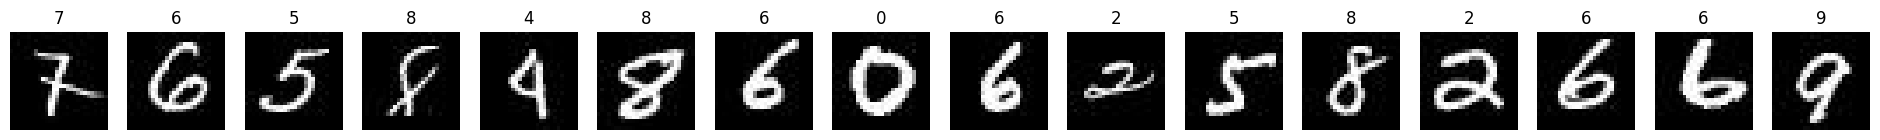

In [ ]:
# Implement your codes here!

import os
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

root_dir = Path("mnist_images")
batch_size = 16
num_workers = 2
pin_memory = True

class MNISTFolderDataset(Dataset):
    def __init__(self, root: Path, split: str, transform=None):
        self.root = root / split
        self.transform = transform
        self.samples = []

        # Scan class folders
        for label_dir in sorted(self.root.iterdir()):  # 0-9
            if label_dir.is_dir():
                label = int(label_dir.name)
                for img_path in sorted(label_dir.iterdir()):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('L')  # grayscale
        if self.transform:
            img = self.transform(img)
        return img, label

        ##### YOUR CODE START #####

transform = transforms.Compose([
    transforms.ToTensor(),  # [0,255] -> [0,1] and shape [C,H,W]
    transforms.Normalize(mean=[0.5], std=[0.5])  # [-1,1]
])


train_ds = MNISTFolderDataset(root_dir, "train", transform=transform)
val_ds   = MNISTFolderDataset(root_dir, "val",   transform=transform)
test_ds  = MNISTFolderDataset(root_dir, "test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)


# implement sanity check here
print("Dataset sizes:")
print(f"Train: {len(train_ds)}")
print(f"Validation: {len(val_ds)}")
print(f"Test: {len(test_ds)}")

images, labels = next(iter(train_loader))

# recover the normalized images into the original space
def denorm(x):
    # x: tensor in [-1,1]
    return (x * 0.5) + 0.5  # -> [0,1]

# implement your code to visualize the actual samples using matplotlib using denorm function above
images = denorm(images)
fig, axes = plt.subplots(1, batch_size, figsize=(batch_size*1.5, 2))
for i in range(batch_size):
    axes[i].imshow(images[i][0], cmap='gray')  # images[i][0] -> channel 0
    axes[i].set_title(str(labels[i].item()))
    axes[i].axis('off')
plt.show()

## Model Architecture

Design and implement a simple convolutional neural network for the MNIST dataset.
You are provided with a description of the architecture below, and your task is to implement the model class so that each layer’s output shape matches the description exactly.


**Model Description**

You may need to include appropriate activation functions in between.

0. input: (B, 1, 28, 28)
1. conv1: output (B, 32, 28, 28)
2. conv2: output (B, 64, 28, 28)
3. maxpool1: output (B, 64, 14, 14)
4. conv3: output (B, 128, 14, 14)
5. conv4: output (B, 128, 14, 14)
6. maxpool2: output (B, 128, 7, 7)
7. flatten: output (B, 128x7x7)
8. fc1: output (B, 256)
9. fc2: output (B, `n_class`)


**Requirements**
1. **Implement a model class** (`MyConvNet`).
- Use `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.Linear` layers.
- Adjust **`kernel_size` / `stride` / `padding`** so that each output shape matches the description above.
2. **Sanity check with zero input**  
- Create a zero tensor with shape **`[batch=10, channels=1, height=28, width=28]`** and run it through the model. Print the output shape.
3. Implementation Constraints
- Keep the architecture identical to the description.
- No BatchNorm or Dropout for this time.


In [ ]:
# Implement your codes here!

import torch
import torch.nn as nn

class MyConvNet(nn.Module):
    def __init__(self, n_class=10):
        super().__init__()
        ##### YOUR CODE START #####
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial size

        self.conv3 = nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128*7*7, 256)
        self.fc2 = nn.Linear(256, n_class)

    def forward(self, x):
        ##### YOUR CODE START #####
        x = self.relu(self.conv1(x))   # (B,32,28,28)
        x = self.relu(self.conv2(x))   # (B,64,28,28)
        x = self.maxpool(x)            # (B,64,14,14)

        x = self.relu(self.conv3(x))   # (B,128,14,14)
        x = self.relu(self.conv4(x))   # (B,128,14,14)
        x = self.maxpool(x)            # (B,128,7,7)

        x = self.flatten(x)            # (B,128*7*7)
        x = self.relu(self.fc1(x))     # (B,256)
        x = self.fc2(x)                # (B,n_class)
        return x

# define your model here & do the sanity check
batch_size = 10
dummy_input = torch.zeros(batch_size, 1, 28, 28)  # zero input
model = MyConvNet(n_class=10)
output = model(dummy_input)
print("Output shape:", output.shape)

Output shape: torch.Size([10, 10])


## Training with GPUs

**Goal**

Train your `MyConvNet` using **SGD** with **momentum** and **weight decay**. For here, do not use `test` set yet.

**Requirements**

0. Use GPUs!
1. **Optimizer**: `torch.optim.SGD`  
- **Momentum**: must be used (non-zero)  
- **Weight Decay**: must be used (non-zero)
2. **Loss**: `nn.CrossEntropyLoss()`
3. **Logging**:
- Define `history` dictionary with the keys of "train_loss" and "val_acc".
- **Store**: `train_loss` (epoch-average) and `val_acc` (epoch) into lists for later plotting
4. **Early Stopping**:  
- Keep track of best `val_acc`  
- When `val_acc` improves against the historical best, **save** model weights to `best.pth`  
- If no improvement for `patience` epochs, **stop**
5. Once your training is done, you should have:
- Plot two figures, each of `history["train_loss"]` and `history["val_acc"]` with epochs.
- Saved `best.pth` containing the best-performing weights on validation

Using device: cuda
Epoch 1/20 | Train Loss: 0.1708 | Val Acc: 0.9743
  --> New best model saved with val_acc=0.9743
Epoch 2/20 | Train Loss: 0.0394 | Val Acc: 0.9878
  --> New best model saved with val_acc=0.9878
Epoch 3/20 | Train Loss: 0.0262 | Val Acc: 0.9898
  --> New best model saved with val_acc=0.9898
Epoch 4/20 | Train Loss: 0.0183 | Val Acc: 0.9903
  --> New best model saved with val_acc=0.9903
Epoch 5/20 | Train Loss: 0.0133 | Val Acc: 0.9895
Epoch 6/20 | Train Loss: 0.0108 | Val Acc: 0.9892
Epoch 7/20 | Train Loss: 0.0085 | Val Acc: 0.9888
Epoch 8/20 | Train Loss: 0.0069 | Val Acc: 0.9905
  --> New best model saved with val_acc=0.9905
Epoch 9/20 | Train Loss: 0.0065 | Val Acc: 0.9900
Epoch 10/20 | Train Loss: 0.0067 | Val Acc: 0.9913
  --> New best model saved with val_acc=0.9913
Epoch 11/20 | Train Loss: 0.0049 | Val Acc: 0.9893
Epoch 12/20 | Train Loss: 0.0056 | Val Acc: 0.9902
Epoch 13/20 | Train Loss: 0.0025 | Val Acc: 0.9897
Epoch 14/20 | Train Loss: 0.0028 | Val Acc: 0

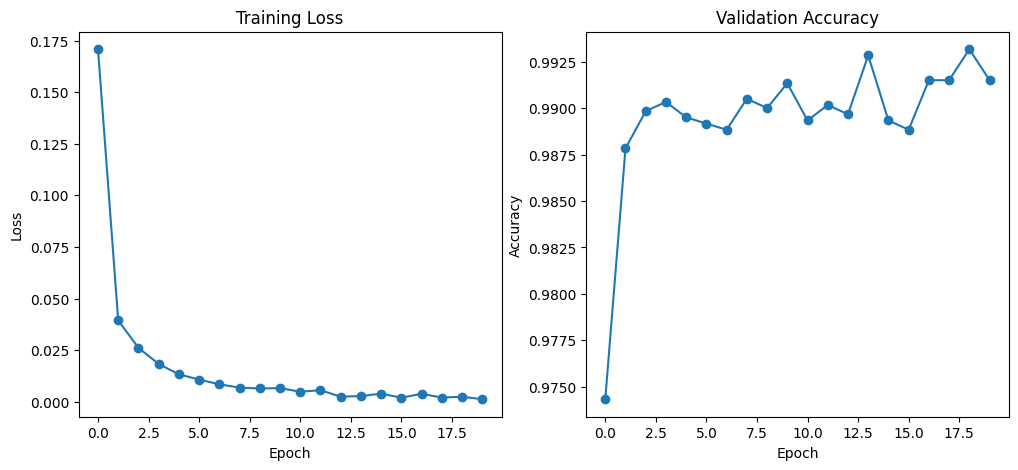

In [ ]:
# Implement your codes here!

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path

device = "cuda"
print("Using device:", device)

# define your hyper-parameters
batch_size = 64
num_workers = 2
learning_rate = 0.01
momentum = 0.9
weight_decay = 1e-4
max_epochs = 20
patience = 5


# define your model, loss, and optimizer
model = MyConvNet(n_class=10).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

# define history for logging
history = {"train_loss": [], "val_acc": []}
best_val_acc = 0.0
epochs_no_improve = 0
best_model_path = Path("best.pth")


# training loop
for epoch in range(1, max_epochs + 1):
    # implement your own code
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    history["train_loss"].append(epoch_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{max_epochs} | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> New best model saved with val_acc={val_acc:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"No improvement for {patience} epochs, stopping early.")
            break

# plot training loss and validation accuracy by epochs

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history["val_acc"], marker='o')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

## Evaluation with Test Set

**Objective**

Load the best-performing model checkpoint (`best.pth`) saved during training above and evaluate it on the **test dataset** to measure the final **test accuracy**. For here, no retraining allowed — this block only loads and evaluates.

Your model must achieve **at least 99% test accuracy** on MNIST.  
If your test accuracy is **below 99%**, you are required to **revisit and iterate on your training block** by adjusting hyperparameters (e.g., learning rate, momentum, weight decay, batch size, or number of epochs) until the requirement is met.

**Requirements**

1. Model Loading
- Recreate the same model architecture (`MyConvNet`) as used for training.
- Load the trained weights:
     ```python
     model.load_state_dict(torch.load("best.pth", map_location=device))
     ```
- Set the model to evaluation mode (`model.eval()`).

2. **Evaluation**
- Use your **test_loader** defined above, with the same preprocessing and normalization as during training.
- Wrap inference inside `torch.no_grad()` to disable gradients.
- Compute **overall test accuracy**

3. **Reporting**
- Print results clearly:
     ```
     Total test samples: <num>
     Correct predictions: <num>
     Test accuracy: <value>
     ```
- You must achieve **≥ 99%** accuracy.  
     If below, go back and **retrain** (adjust hyperparameters, increase epochs, etc.) until it meets the target.




In [ ]:
# Implement your codes here!
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = MyConvNet(n_class=10).to(device)

# load model from best.pth
model.load_state_dict(torch.load("best.pth", map_location=device))
model.eval()  # evaluation mode
print("Loaded best model checkpoint.")

# iterate test samples using test_loader above
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# print the final result

print(f"Total test samples: {total}")
print(f"Correct predictions: {correct}")
test_acc = correct / total
print(f"Test accuracy: {test_acc*100:.2f}%")

# Check if requirement is met
if test_acc >= 0.99:
    print("Test accuracy requirement met (≥ 99%).")
else:
    print("Test accuracy below 99%.")

Using device: cuda
Loaded best model checkpoint.
Total test samples: 10000
Correct predictions: 9932
Test accuracy: 99.32%
Test accuracy requirement met (≥ 99%).


## Submission

When you are ready to submit your materials:
1. Download best.pth to your local computer
2. Download your COSE-474-02-Assignment_1.ipynb file (make sure **all outputs are kept**) to your local computer
3. Create a zip file (e.g., 2025000000_jungbeomlee.zip), containing `best.pth` and `COSE-474-02-Assignment_1.ipynb` (DO NOT include mnist_images folder, it's too large!)




In [ ]:
from google.colab import files

files.download('best.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>